In [15]:
#Import dataset
import pandas as pd

df = pd.read_csv("data/Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
# List down the column names
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [ ]:
# Count the data volume wrt each column
df.count()

Store           6435
Date            6435
Weekly_Sales    6435
Holiday_Flag    6435
Temperature     6435
Fuel_Price      6435
CPI             6435
Unemployment    6435
dtype: int64

In [ ]:
# Try to find whether there are any nulls
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [ ]:
# Trying find the spread of the data by seeing unique values
df.nunique()

Store             45
Date             143
Weekly_Sales    6435
Holiday_Flag       2
Temperature     3528
Fuel_Price       892
CPI             2145
Unemployment     349
dtype: int64

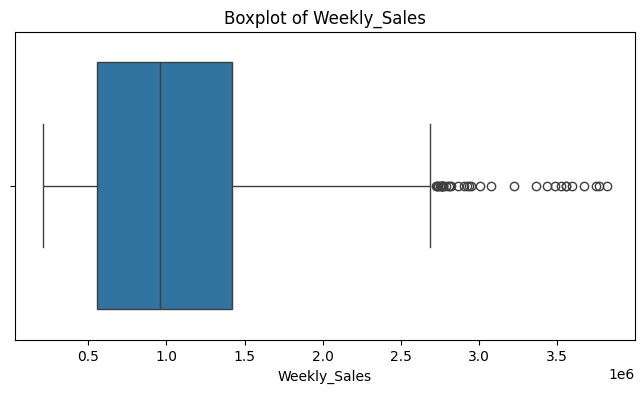

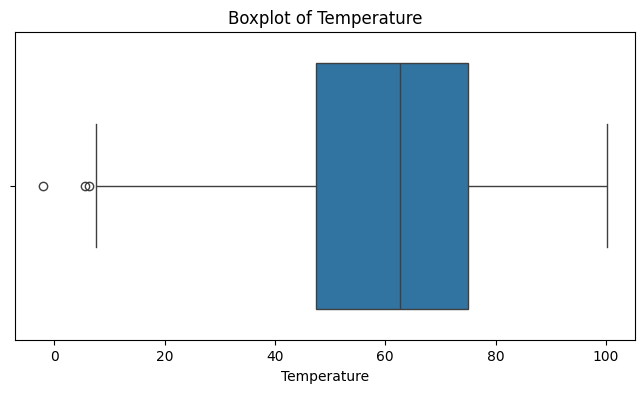

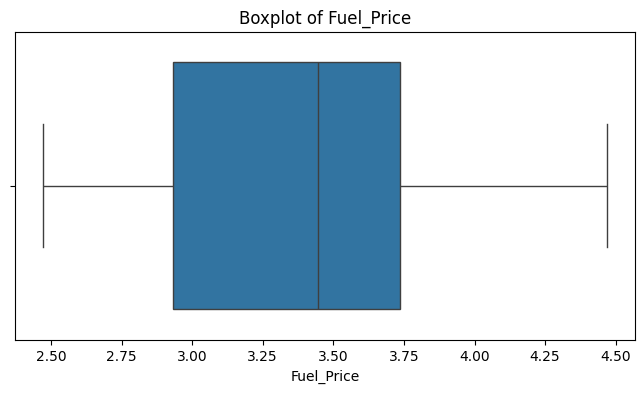

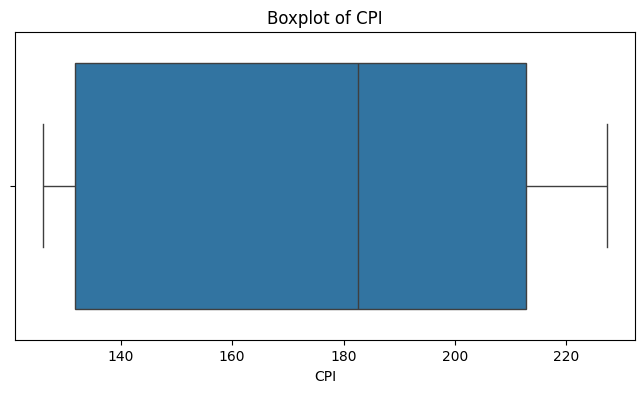

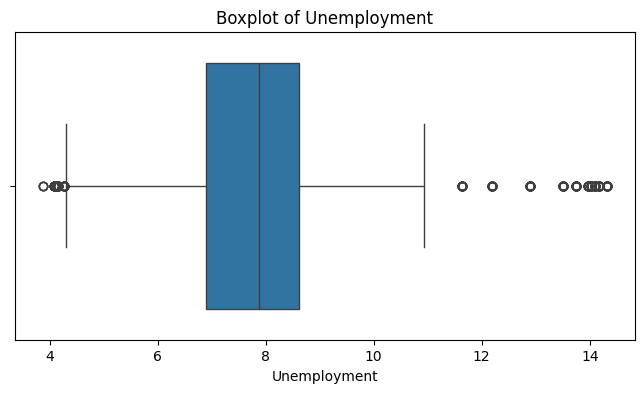

In [ ]:
#Accessing the Outliers
import matplotlib.pyplot as plt
import seaborn as sns

cols_for_outliers = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]

for col in cols_for_outliers:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

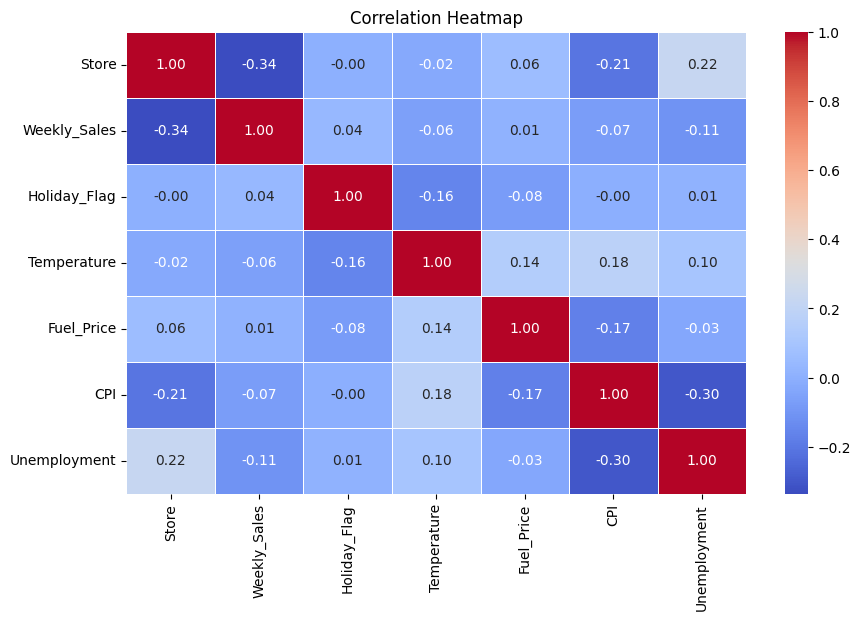

In [ ]:
# Heat map to see the correlation between features
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for numeric columns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [31]:
# Features (Independent variables)
X = df[['Store', 'Holiday_Flag', 'Temperature',
        'Fuel_Price', 'CPI', 'Unemployment']]

# Target (Dependent variable)
y = df['Weekly_Sales']

In [32]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5791, 6)
X_test : (644, 6)
y_train: (5791,)
y_test : (644,)


In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred = model.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 428805.63013846666
Mean Squared Error  : 264831169589.87317
Root Mean Squared Error : 514617.4983323761
R² Score : 0.1609457786019145


In [36]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head(10))

          Actual     Predicted
2436  1138800.32  1.203469e+06
3361  1304850.67  1.100501e+06
233   1769296.25  1.264931e+06
3667  1077640.13  1.111577e+06
5011   428851.99  7.458401e+05
4850  1004523.59  9.237184e+05
3891  1523410.71  9.077419e+05
1699  1014898.78  1.209143e+06
2742  1955896.59  1.007231e+06
1703   958667.23  1.210130e+06


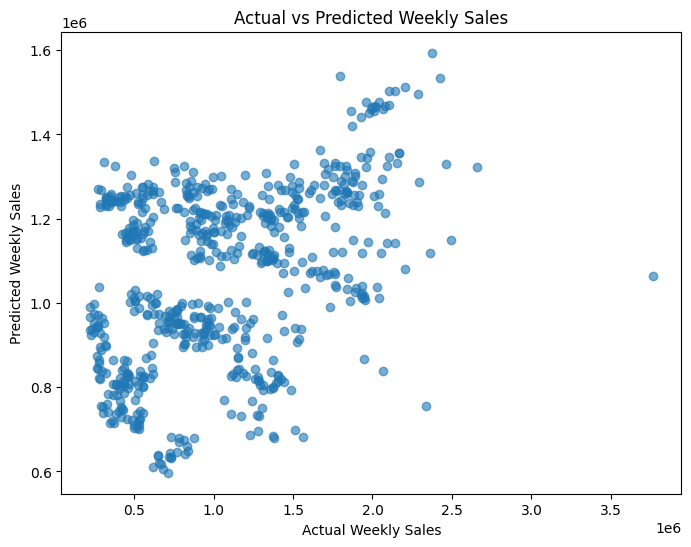

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")
plt.show()

In [38]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})

print(coefficients)

        Feature   Coefficient
0         Store -15184.330054
1  Holiday_Flag  58413.553856
2   Temperature  -1068.825119
3    Fuel_Price   1584.085198
4           CPI  -2309.876230
5  Unemployment -22885.087255


In [39]:
#Now create models with every available regression models
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


In [40]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [41]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

In [42]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

y_pred_elastic = elastic.predict(X_test)

In [43]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [45]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [47]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)

ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)

In [48]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [49]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')

svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [53]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(random_state=42)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1063
[LightGBM] [Info] Number of data points in the train set: 5791, number of used features: 6
[LightGBM] [Info] Start training from score 1046767.412091


In [54]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(verbose=0)

cat.fit(X_train, y_train)

y_pred_cat = cat.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_test, y_pred):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    }

In [56]:
results = []

results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))
results.append(evaluate_model("Ridge", y_test, y_pred_ridge))
results.append(evaluate_model("Lasso", y_test, y_pred_lasso))
results.append(evaluate_model("Elastic Net", y_test, y_pred_elastic))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("Extra Trees", y_test, y_pred_et))
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))
results.append(evaluate_model("AdaBoost", y_test, y_pred_ada))
results.append(evaluate_model("KNN", y_test, y_pred_knn))
results.append(evaluate_model("SVR", y_test, y_pred_svr))
results.append(evaluate_model("XGBoost", y_test, y_pred_xgb))
results.append(evaluate_model("LightGBM", y_test, y_pred_lgb))
results.append(evaluate_model("CatBoost", y_test, y_pred_cat))

In [58]:
results_df = pd.DataFrame(results)

print(results_df)

                Model            MAE           RMSE  R2 Score
0   Linear Regression  428805.630138  514617.498332  0.160946
1               Ridge  428807.604628  514620.378261  0.160936
2               Lasso  428805.660066  514617.541148  0.160946
3         Elastic Net  429121.621492  515117.161832  0.159316
4       Decision Tree   98817.792826  192966.124139  0.882027
5       Random Forest   77678.973366  149060.379305  0.929604
6         Extra Trees   75209.623511  145135.900053  0.933262
7   Gradient Boosting  135463.280427  195650.535851  0.878722
8            AdaBoost  396862.521712  462646.386705  0.321860
9                 KNN  185304.640494  290572.107583  0.732497
10                SVR  464801.289195  568468.146830 -0.023843
11            XGBoost   66544.153167  113177.210351  0.959417
12           LightGBM   70543.496139  121406.682919  0.953301
13           CatBoost   69066.276078  115392.641606  0.957813


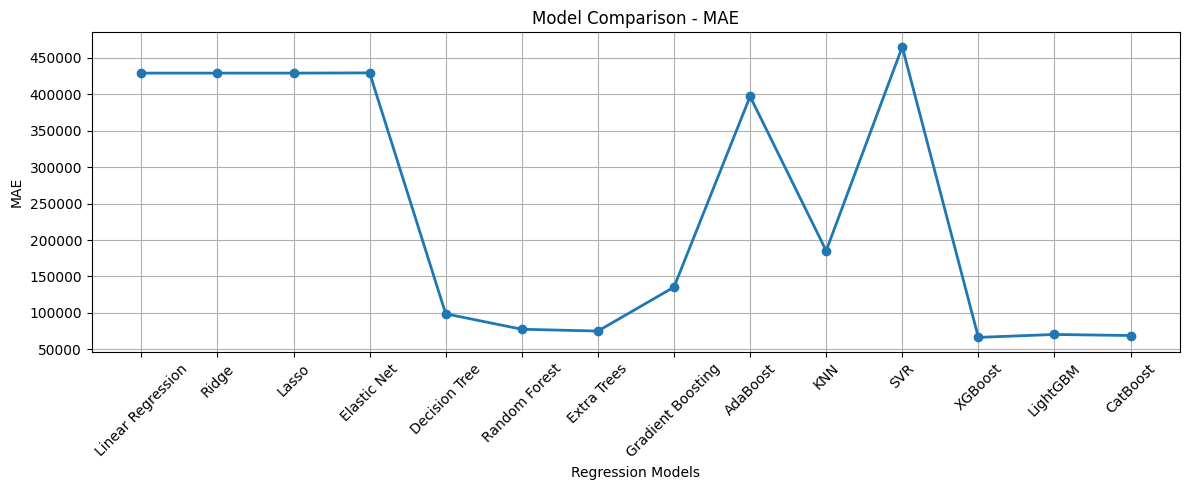

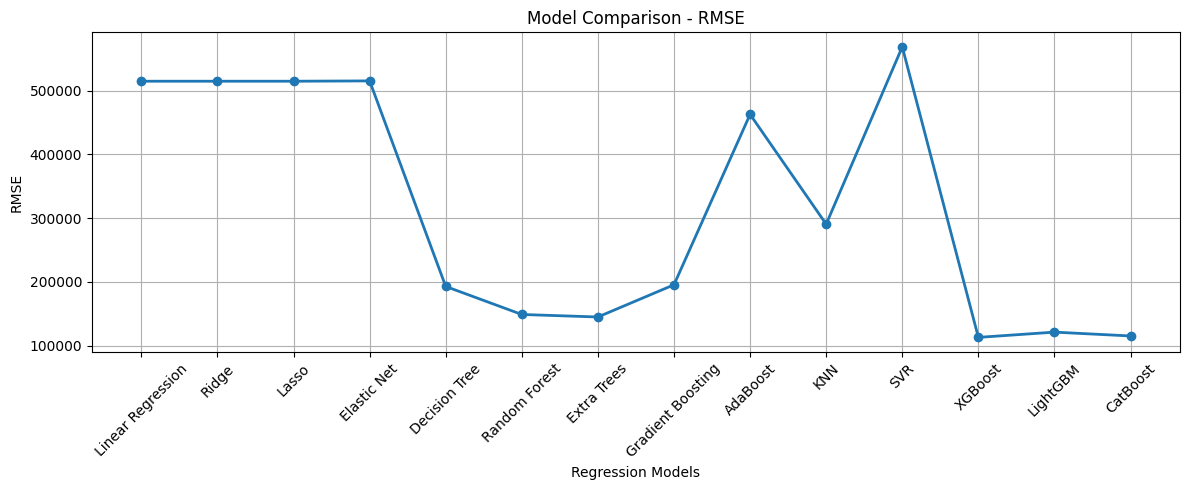

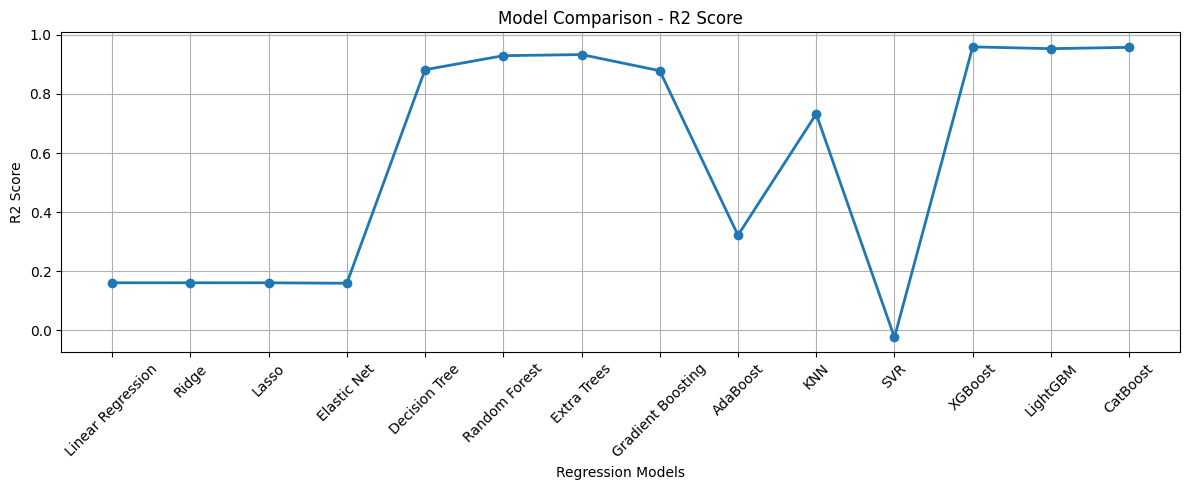

In [62]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'RMSE', 'R2 Score']

for metric in metrics:
    plt.figure(figsize=(12,5))
    plt.plot(results_df['Model'],
             results_df[metric],
             marker='o',
             linewidth=2)

    plt.title(f'Model Comparison - {metric}')
    plt.xlabel('Regression Models')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# XGBoost , LightGBM and Catboost models are good in terms of performance metrics